In [1]:
!pip install gdown


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# %%
# ==============================
# Import poackages
# ==============================
import os
import time
from pathlib import Path

import gdown
from loguru import logger
from python_calamine import CalamineWorkbook

import polars as pl

In [3]:
# %%
# ==============================
# Download data
# ==============================


folder_path: str = r"/home/user/py-pannguyen-learn/data/staging/21th"
gg_folder_url: str = (
    "https://drive.google.com/drive/folders/1Kgq9iPgcyCPclC_d-BLmV_lA3dq-84MW"
)

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# gdown.download_folder(url=gg_folder_url, output=folder_path, quiet=False)



Retrieving folder contents


Processing file 1c_spxMVDCOumykftsRl2h7vFJk3DoA-2 Used_Car_Sales_dataset.xlsx
Processing file 1LP0_YmGSof8Cbqm8Pv8VrQaL-MMospS722wXZO_GqPQ Đề bài


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1c_spxMVDCOumykftsRl2h7vFJk3DoA-2
From (redirected): https://drive.google.com/uc?id=1c_spxMVDCOumykftsRl2h7vFJk3DoA-2&confirm=t&uuid=2cb06f03-e0a5-40b4-ad2d-d2042f6e5b7b
To: /home/user/py-pannguyen-learn/data/staging/21th/Used_Car_Sales_dataset.xlsx
100%|██████████| 52.7M/52.7M [00:00<00:00, 144MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1LP0_YmGSof8Cbqm8Pv8VrQaL-MMospS722wXZO_GqPQ
From (redirected): https://docs.google.com/document/d/1LP0_YmGSof8Cbqm8Pv8VrQaL-MMospS722wXZO_GqPQ/export?format=docx
To: /home/user/py-pannguyen-learn/data/staging/21th/Đề bài.docx
213kB [00:00, 759kB/s] 
Download completed


['/home/user/py-pannguyen-learn/data/staging/21th/Used_Car_Sales_dataset.xlsx',
 '/home/user/py-pannguyen-learn/data/staging/21th/Đề bài.docx']

In [4]:
# %%
# ==============================
# Get all files in origin folder
# ==============================

files = [
    file
    for file in Path(folder_path).iterdir()
    if file.is_file() and file.suffix in [".xlsx", ".xls"]
]
logger.info(f"{files = }")


2026-06-19 10:24:08.880 | INFO     | __main__:<module>:11 - files = [PosixPath('/home/user/py-pannguyen-learn/data/staging/21th/Used_Car_Sales_dataset.xlsx')]


In [5]:
# %%
# ==============================
# Transfer from other file type to parquet/sql/csv (if need)
# ==============================


OUTPUT_DIR: str = r"/home/user/py-pannguyen-learn/data/raw/21th"


@logger.catch
def excel_to_parquet(file_path: Path, sheet_name: str) -> str:
    """Convert Excel sheet to Parquet using Polars natively."""
    logger.info(f"Convert excel to parquet: {str(file_path)} - {sheet_name}")
    file_name = file_path.stem
    parquet_path = f"{OUTPUT_DIR}/{file_name}_{sheet_name}.parquet"
    if Path(parquet_path).is_file() and os.path.getsize(parquet_path) > 0:
        logger.info(
            f"{parquet_path} exist and have data. Size: {os.path.getsize(parquet_path) / 1024**2: .2f}(MB)."
        )
        return parquet_path
    start = time.perf_counter()
    df = pl.read_excel(
        str(file_path), sheet_name=sheet_name, has_header=True, infer_schema_length=0
    )

    df.lazy().sink_parquet(parquet_path, mkdir=True)
    end = time.perf_counter()
    logger.success(
        "Complete transfer excel to parquet. "
        f"Destination: {parquet_path}. "
        f"Sheet_name: {sheet_name}. "
        f"Time consuming: {end - start: .2f}(s). "
        f"Data size: {df.estimated_size(unit='mb'): .2f}(MB), "
        f"{df.height} rows, {df.width} columns."
    )
    return parquet_path


des_path_list: list[str] = []
for file in files:
    sheets = CalamineWorkbook.from_path(str(file)).sheet_names
    for sheet in sheets:
        des_path = excel_to_parquet(file, sheet)
        des_path_list.append(des_path)

2026-06-19 10:24:09.184 | INFO     | __main__:excel_to_parquet:13 - Convert excel to parquet: /home/user/py-pannguyen-learn/data/staging/21th/Used_Car_Sales_dataset.xlsx - Sheet1
2026-06-19 10:24:09.186 | INFO     | __main__:excel_to_parquet:17 - /home/user/py-pannguyen-learn/data/raw/21th/Used_Car_Sales_dataset_Sheet1.parquet exist and have data. Size:  10.87(MB).
2026-06-19 10:24:09.186 | INFO     | __main__:excel_to_parquet:17 - /home/user/py-pannguyen-learn/data/raw/21th/Used_Car_Sales_dataset_Sheet1.parquet exist and have data. Size:  10.87(MB).


In [6]:
# %%
file_path: str = (
    r"/home/user/py-pannguyen-learn/data/raw/21th"
)
df: pl.LazyFrame = pl.scan_parquet(file_path)
logger.info(
    f"rows: {df.select(pl.len()).collect().item(): ,}, "
    f"cols: {len(df.collect_schema())}, "
    f"column names: {df.collect_schema().names()}"
)

pl.Config(set_tbl_cols=-1, set_tbl_rows=-1)
rows = df.select(pl.len()).collect().item()
col_names = df.collect_schema().names()

2026-06-19 10:24:10.612 | INFO     | __main__:<module>:6 - rows:  371,404, cols: 22, column names: ['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model', 'kilometer', 'monthOfRegistration', 'fuelType', 'brand', 'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode', 'Lattitude', 'Longitude', 'lastSeen']


## Preprocessing

### Cast type

In [7]:
# %%
# Cast type

df = df.with_columns(
    [pl.col(col).cast(pl.Float64) for col in ["price", "powerPS", "kilometer"]]
).with_columns(
    [pl.col(col).cast(pl.Int64) for col in ["monthOfRegistration", "nrOfPictures"]]
)

###

## EDA

### Null count

In [8]:
# Not null percentage
(df.collect().count() / rows * 100).transpose(include_header=True).rename(
    {"column_0": "Not null(%)"}
)

column,Not null(%)
str,f64
"""dateCrawled""",100.0
"""name""",99.995961
"""seller""",100.0
"""offerType""",100.0
"""price""",100.0
"""abtest""",100.0
"""vehicleType""",89.807864
"""yearOfRegistration""",100.0
"""gearbox""",94.56064


In [9]:
# %%
# Missing values
# This part exists in count null value, reshow to know null count
col_names = df.collect_schema().names()
df_dtype_listing = pl.DataFrame(
    {"column": col_names, "dtype": [str(d) for d in df.collect_schema().dtypes()]}
)
df_null_count = (
    df.null_count()
    .collect()
    .transpose(include_header=True)
    .rename({"column_0": "null_count"})
)
df_null_count = df_null_count.with_columns(
    (pl.col("null_count") / rows * 100).alias("null_percentage(%)")
)
df_null_count = df_null_count.filter(pl.col("null_percentage(%)") > 0)

df_null_count = df_null_count.join(df_dtype_listing, on="column", how="left")
df_null_count = df_null_count.sort(by="null_percentage(%)", descending=True)

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_null_count)

shape: (6, 4)
┌───────────────────┬────────────┬────────────────────┬────────┐
│ column            ┆ null_count ┆ null_percentage(%) ┆ dtype  │
│ ---               ┆ ---        ┆ ---                ┆ ---    │
│ str               ┆ u32        ┆ f64                ┆ str    │
╞═══════════════════╪════════════╪════════════════════╪════════╡
│ notRepairedDamage ┆ 72028      ┆ 19.393437          ┆ String │
│ vehicleType       ┆ 37854      ┆ 10.192136          ┆ String │
│ fuelType          ┆ 33377      ┆ 8.98671            ┆ String │
│ model             ┆ 20475      ┆ 5.512865           ┆ String │
│ gearbox           ┆ 20202      ┆ 5.43936            ┆ String │
│ name              ┆ 15         ┆ 0.004039           ┆ String │
└───────────────────┴────────────┴────────────────────┴────────┘


### Visualize

In [10]:
# !pip install pyarrow missingno

<Axes: >

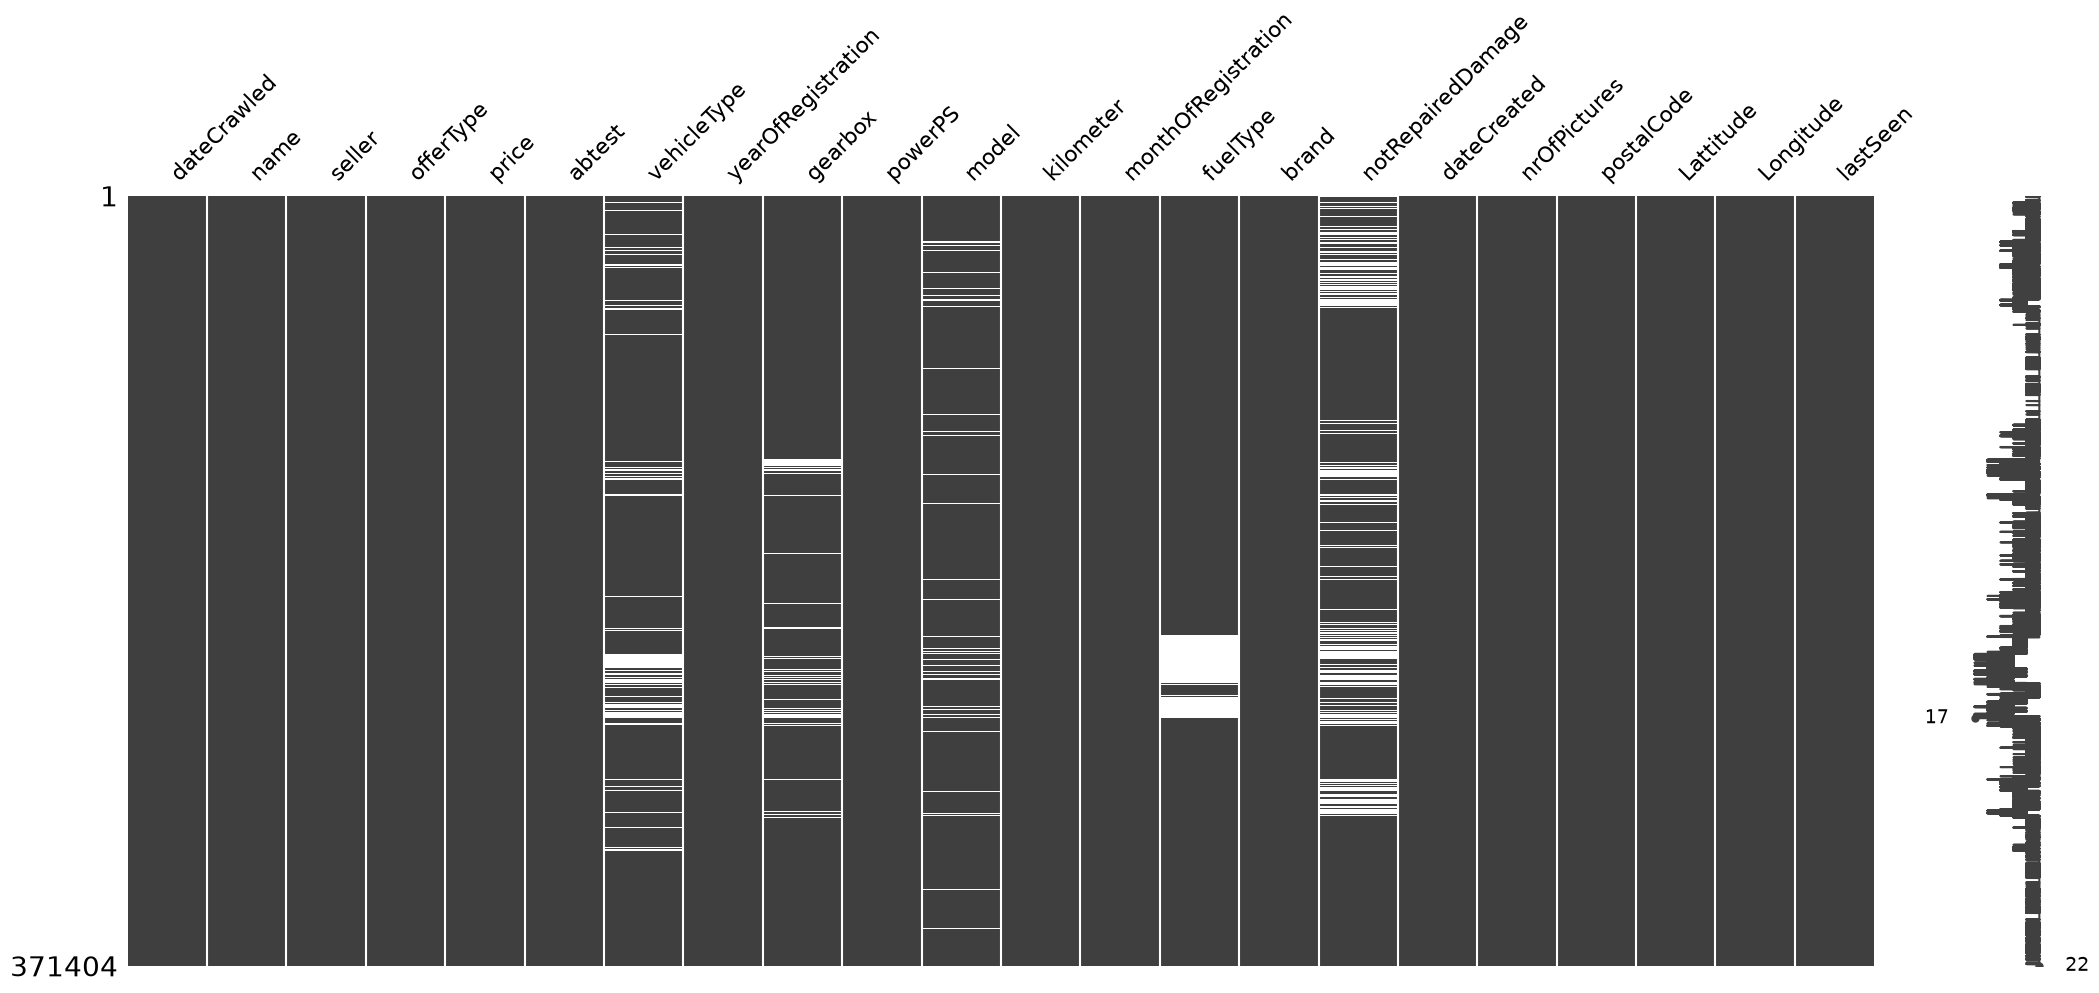

In [11]:
# %%
# Visualize null values
import missingno as msno

msno.matrix(df.collect().to_pandas())

<Axes: >

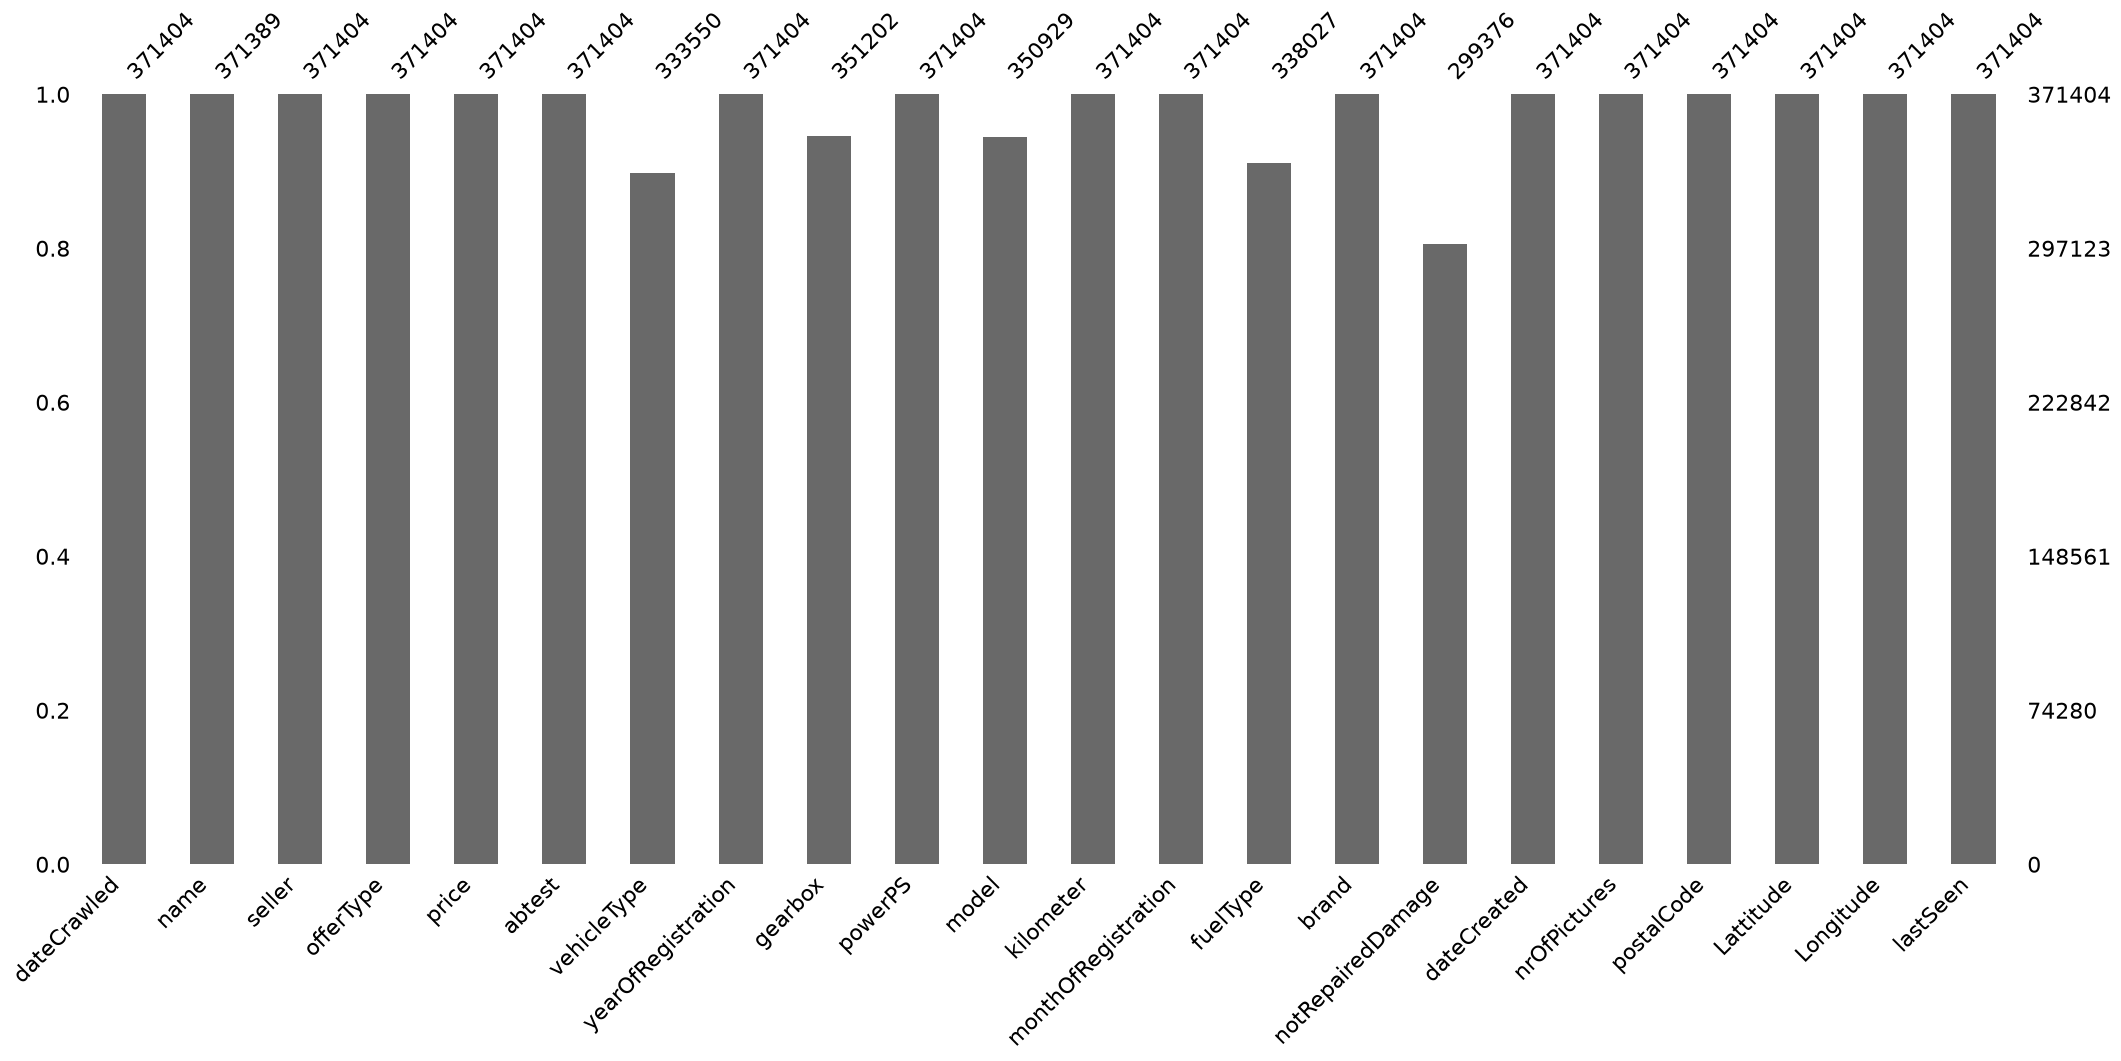

In [12]:
# %%
msno.bar(df.collect().to_pandas())

<Axes: >

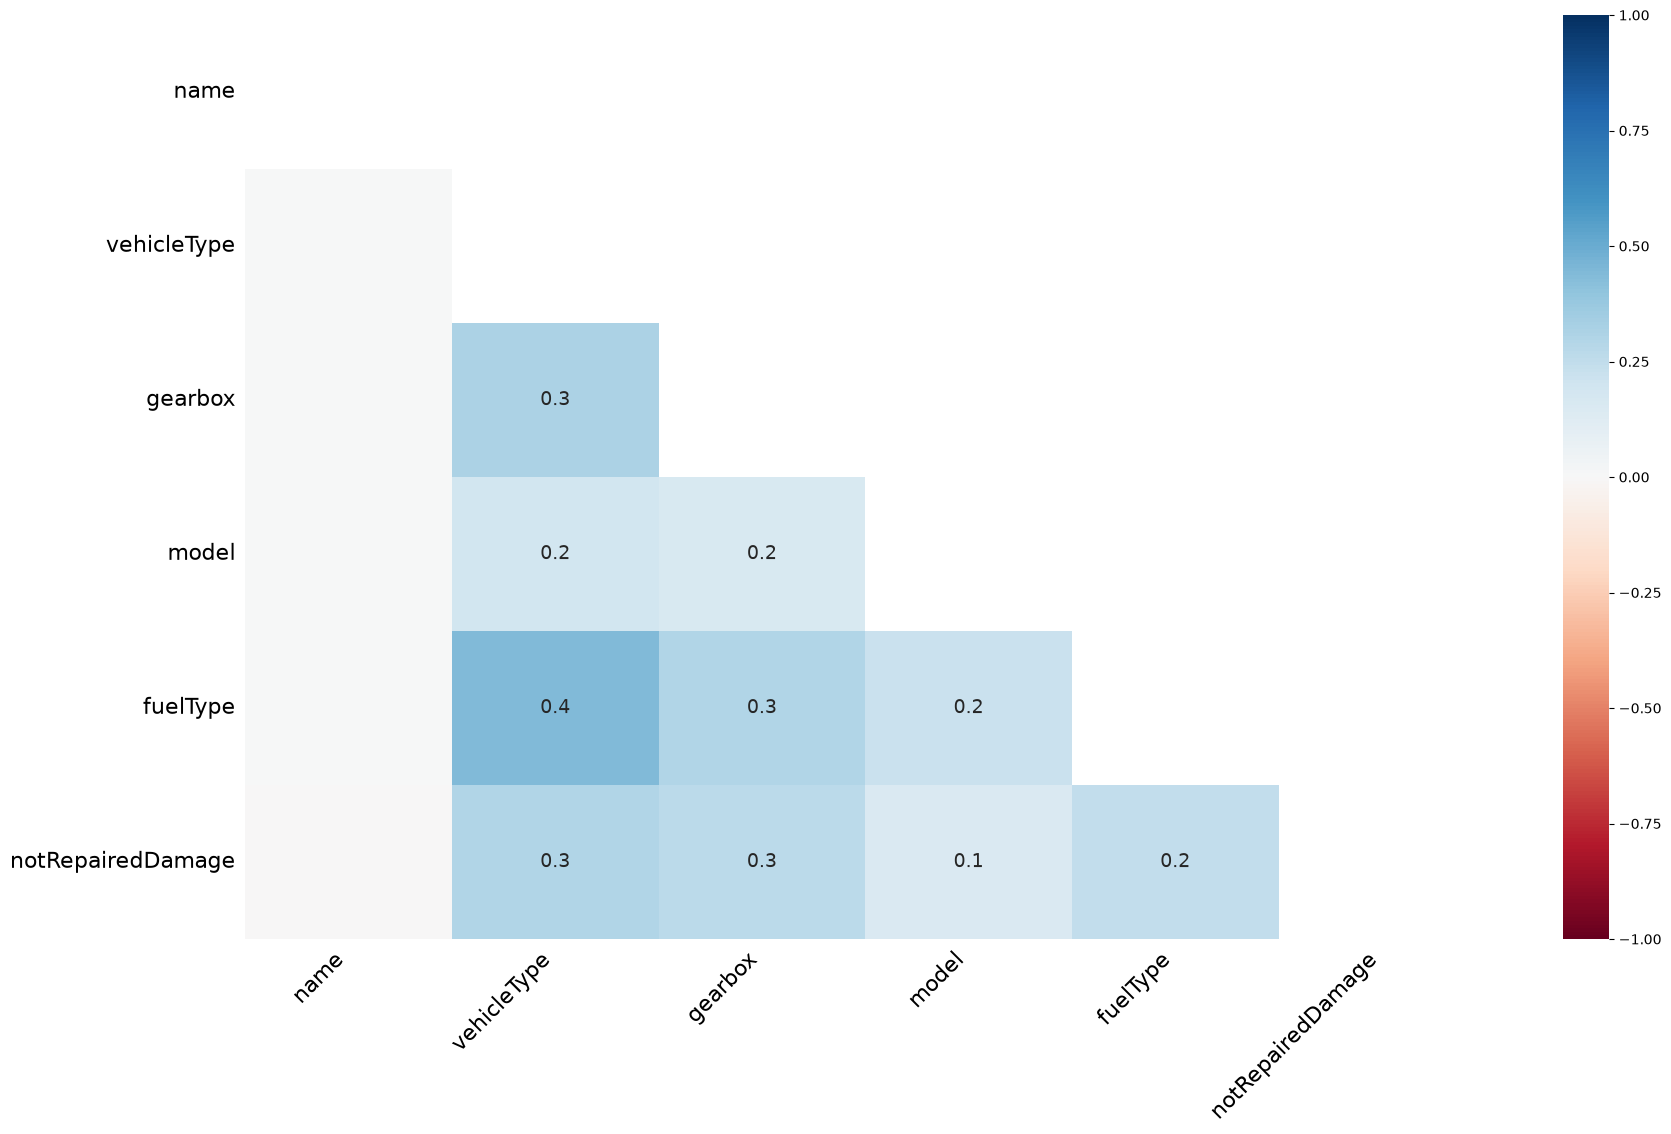

In [13]:
# %%
msno.heatmap(df.collect().to_pandas())  # Values near +1 = maybe missing together (MNAR)


<Axes: >

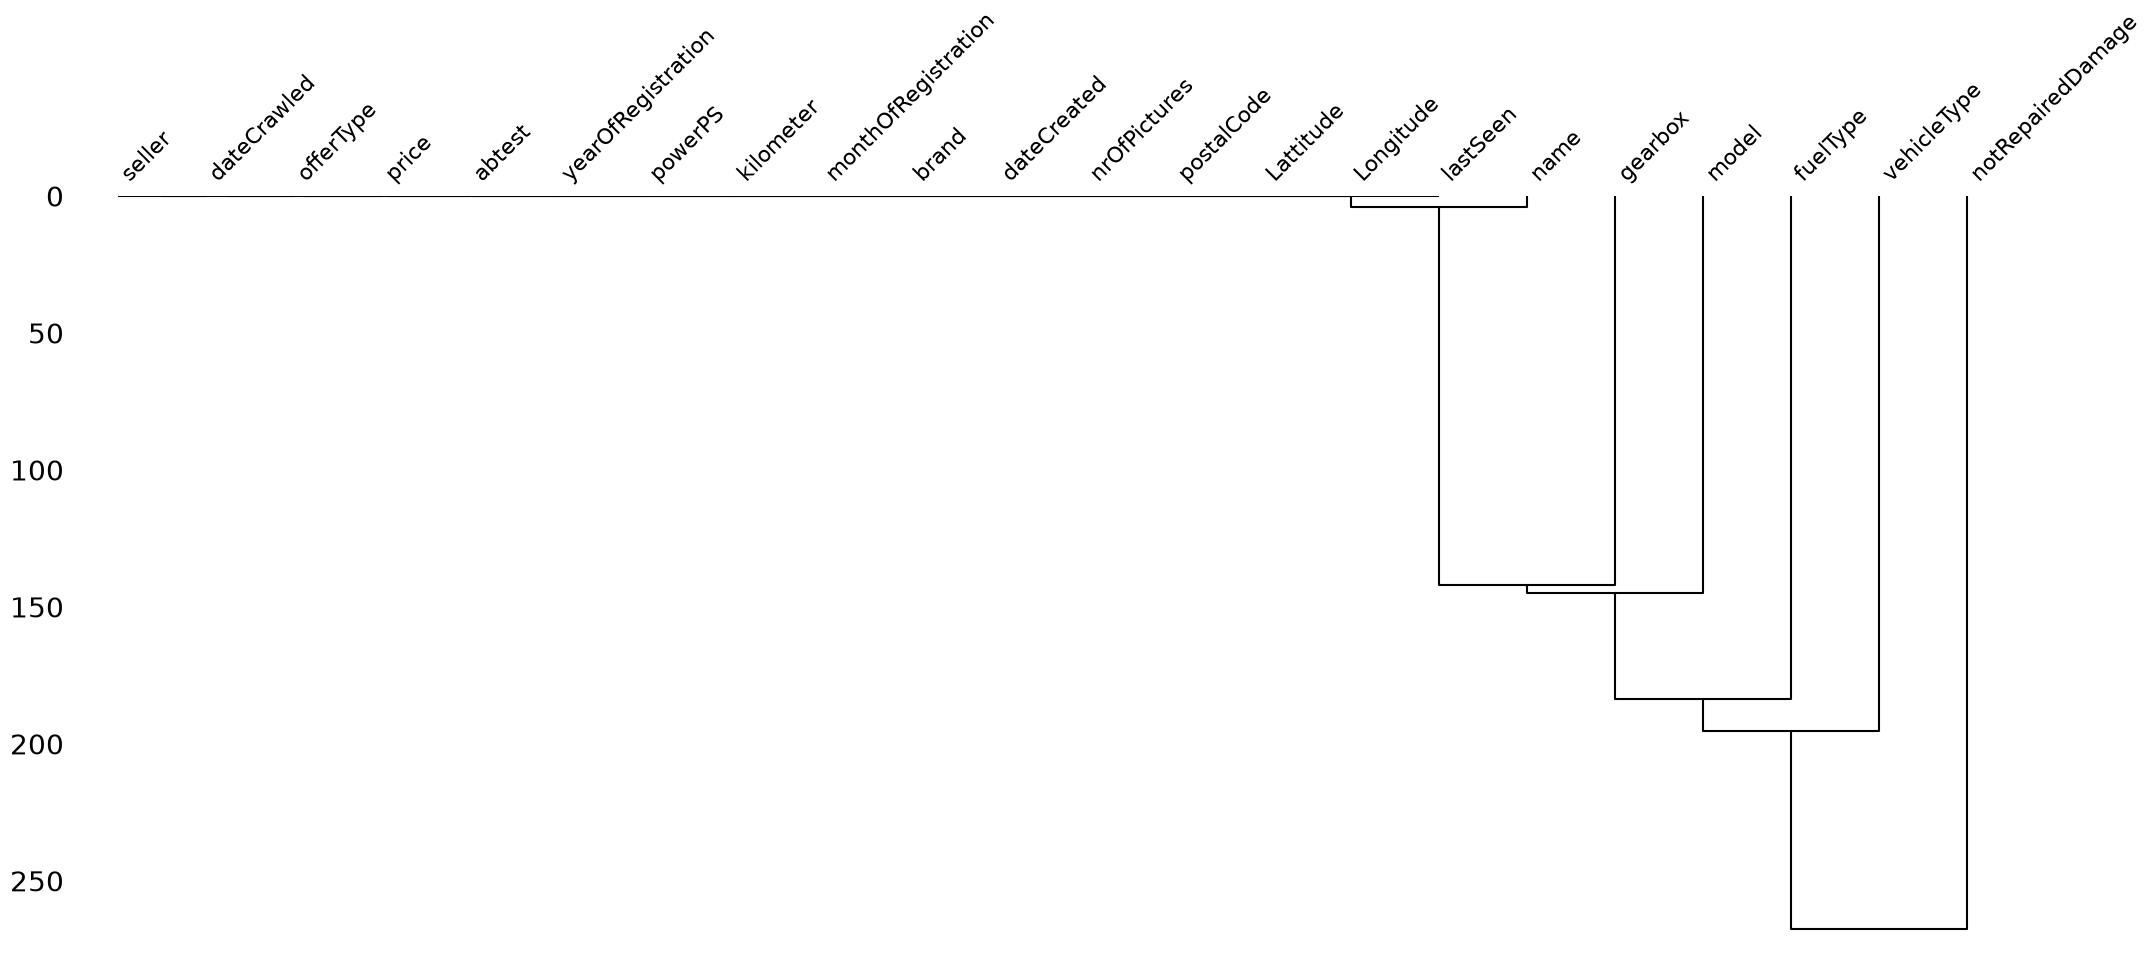

In [14]:
# %%
msno.dendrogram(
    df.collect().to_pandas()
)  # Tight cluster = same rows -> can be missing together

### Explode coumns has incorrect values (ex: price <0,..) or suspicious data

In [15]:
# %%
invalid_num_res: dict[str, int] = {
    "price": 0,
    "powerPS": 0,
    "kilometer": 0,
    # "monthOfRegistration": 0,
}
for col in invalid_num_res.keys():
    invalid_num_res[col] = df.filter(pl.col(col) <= 0).collect().height
    logger.info(
        f"col: {col}, amount: {invalid_num_res[col]}, percentage: {invalid_num_res[col] / rows * 100}"
    )
invalid_num_res
df.filter((pl.col("price") <= 0) & (pl.col("powerPS") <= 0)).collect().height

2026-06-19 10:24:31.199 | INFO     | __main__:<module>:10 - col: price, amount: 10776, percentage: 2.9014227095023206
2026-06-19 10:24:31.306 | INFO     | __main__:<module>:10 - col: powerPS, amount: 40812, percentage: 10.988573090219814
2026-06-19 10:24:31.379 | INFO     | __main__:<module>:10 - col: kilometer, amount: 0, percentage: 0.0


3868

### Fill null for string, category,.. (that no need to statistic or analyst)

In [16]:
# %%
# price, powerPS
# 1. convert == 0 to na
import numpy as np

df = df.with_columns(
    pl.when(pl.col("price") <= 0).then(None).otherwise(pl.col("price")).alias("price"),
    pl.when(pl.col("powerPS") <= 0)
    .then(None)
    .otherwise(pl.col("powerPS"))
    .alias("powerPS"),
)

In [17]:
# %%
(df.select(pl.all().null_count()).collect())

dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,Lattitude,Longitude,lastSeen
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,15,0,0,10776,0,37854,0,20202,40812,20475,0,0,33377,0,72028,0,0,0,0,0,0


In [18]:
# %%
# Fill null values for string value
null_cols = df_null_count["column"].to_list()

df = df.with_columns([pl.col(col).fill_null("unknown") for col in null_cols])

null_cols.remove("name")
for col in null_cols:
    print(df.select(pl.col(col).value_counts(sort=True)).unnest(col).collect())

shape: (3, 2)
┌───────────────────┬────────┐
│ notRepairedDamage ┆ count  │
│ ---               ┆ ---    │
│ str               ┆ u32    │
╞═══════════════════╪════════╡
│ nein              ┆ 263112 │
│ unknown           ┆ 72028  │
│ ja                ┆ 36264  │
└───────────────────┴────────┘
shape: (9, 2)
┌─────────────┬───────┐
│ vehicleType ┆ count │
│ ---         ┆ ---   │
│ str         ┆ u32   │
╞═════════════╪═══════╡
│ limousine   ┆ 95856 │
│ kleinwagen  ┆ 80000 │
│ kombi       ┆ 67555 │
│ unknown     ┆ 37854 │
│ bus         ┆ 30187 │
│ cabrio      ┆ 22889 │
│ coupe       ┆ 19007 │
│ suv         ┆ 14696 │
│ andere      ┆ 3360  │
└─────────────┴───────┘
shape: (8, 2)
┌──────────┬────────┐
│ fuelType ┆ count  │
│ ---      ┆ ---    │
│ str      ┆ u32    │
╞══════════╪════════╡
│ benzin   ┆ 223759 │
│ diesel   ┆ 107729 │
│ unknown  ┆ 33377  │
│ lpg      ┆ 5376   │
│ cng      ┆ 571    │
│ hybrid   ┆ 280    │
│ andere   ┆ 208    │
│ elektro  ┆ 104    │
└──────────┴────────┘
shape: (252

### Investiage more to detect missing type, and determine missing strategy (numeric columns or that need analyst, statistic)
- Statistic to guess that MCAR, MAR, or MCAR
- Count null / totla data
- Count data missing in group column
=> determine they are independent or dependent
=> if dependent -> MAR
=> find or think about fill missing data strategy
=> do strategy => record result
=> compare with before fill strategy => ensure data quality, or at least filling strategy no cause bias -> can apply -> choose the most suitable among applied strategies
=> report

- If MCAR and not overlap with other columns so much (threshold? son't know, but permantly < 5%): drop. Ex: price missing : 2.9% -> can drop
- < 5% bot overlap other column? -> independent or dependent -> ex: price missing 2.9%, powerPH: 10,9%, but they are overlap ~4000 rows (~ 39%) -> slightly issue -> maybe not indepedent -> need record
- 5-15%: basic imputate like mean, median, .... Ex: powerPH: 10,9%, can not drop -> check normal distribution -> mean is able, if skewed distribution -> median is able -> if data is missing by group -> fill misisng mean/median group ?
- 15 - 40% : maybe need linear regression, KNN, MICE to impute -> run to check and judge -> record

if when group missing based on other colums/group, if some group values contain more data than others, is it real missing with structural reason rather than missing only -> add flag/category rather than fill missing data?
how to determine that this group data is more than other, and detect it is issue?
thresho;d to detect which group is more than other?
thresold to choose group to fill median?

realistic: find factors can effect on powerPS: brand, vehicle type, model,... -> run check per group, if result of missing group is not hundred rows, just dozens row -> maybe good

Or, a suggestion: test which grouping is more predictive directly: temporarily take rows where powerPS IS valid, mask 20% of them as if missing, impute with each grouping strategy, and compare imputed vs. actual. Whichever grouping gets closer wins — that's a much stronger justification than guessing upfront.

- >= 70%: can drop, missing is no meaning

=> fill and check -> record detai: how many missing, missing type, independent?, filling strategies applied? result, which choose

another need to check: MAE, RMSE, 

column price

In [19]:
# %%
(
    df.filter((pl.col("price").is_null()) & (pl.col("powerPS").is_null()))
    .group_by("vehicleType")
    .len()
    .sort("len", descending=True)
    .with_columns((pl.col("len") / rows * 100).alias("percent"))
).collect()

vehicleType,len,percent
str,u32,f64
"""unknown""",2279,0.613618
"""kleinwagen""",477,0.128432
"""limousine""",372,0.10016
"""kombi""",299,0.080505
"""bus""",142,0.038233
"""cabrio""",89,0.023963
"""coupe""",84,0.022617
"""andere""",65,0.017501
"""suv""",61,0.016424


In [20]:
# %%
(
    df.filter((pl.col("price").is_null()) & (pl.col("powerPS").is_null()))
    .group_by("brand")
    .len()
    .sort("len", descending=True)
    .with_columns((pl.col("len") / rows * 100).alias("percent"))
).collect()

brand,len,percent
str,u32,f64
"""volkswagen""",813,0.218899
"""opel""",464,0.124931
"""sonstige_autos""",450,0.121162
"""bmw""",357,0.096122
"""ford""",276,0.074313
"""mercedes_benz""",239,0.06435
"""audi""",228,0.061389
"""renault""",197,0.053042
"""fiat""",117,0.031502


In [21]:
# %%
(
    df.filter((pl.col("price").is_null()) & (pl.col("powerPS").is_null()))
    .group_by("seller")
    .len()
    .sort("len", descending=True)
    .with_columns((pl.col("len") / rows * 100).alias("percent"))
).collect()

seller,len,percent
str,u32,f64
"""privat""",3868,1.041454


figure out that price and powerPS is missing independence or not

In [22]:
# %%
df_missing = df.with_columns(
    price_missing=(pl.col("price").is_null()),
    power_missing=(pl.col("powerPS").is_null()),
)
(
    df_missing.group_by("price_missing", "power_missing")
    .len()
    .with_columns((pl.col("len") / rows * 100).alias("percent"))
    .collect()
)

price_missing,power_missing,len,percent
bool,bool,u32,f64
true,false,6908,1.859969
false,false,323684,87.151458
true,true,3868,1.041454
false,true,36944,9.94712


In [23]:
# %%
(df_missing.group_by("price_missing").agg(pl.mean("power_missing")).collect())

price_missing,power_missing
bool,f64
true,0.358946
false,0.102444


If they were completely independent, we'd expect: P(price missing) × P(power missing) ~ real group missing percentage, meaning:
P(price missing) = 10776 / 371404 ≈ 2.90%
P(power missing) = 40812 / 371404 ≈ 10.99%
 -> 2.90% × 10.99% ≈ 0.319%
But reality: price missing and powerPS missing is ~ 1.04% -> Actual overlap is over 3 times larger than expected.
=> maybe price_missing and power_missing are not independent.

In [24]:
# %%
df_1 = df.with_columns(
    pl.when(pl.col("price").is_null() & pl.col("powerPS").is_null())
    .then(pl.lit("both_missing"))
    .when(pl.col("price").is_null())
    .then(pl.lit("price_missing"))
    .when(pl.col("powerPS").is_null())
    .then(pl.lit("power_missing"))
    .otherwise(pl.lit("complete"))
    .alias("missing_group")
)
(
    df_1.group_by("missing_group", "vehicleType")
    .len()
    .sort("len", descending=True)
    .collect()
)
(df_1.group_by("missing_group", "brand").len().sort("len", descending=True).collect())


missing_group,brand,len
str,str,u32
"""complete""","""volkswagen""",69545
"""complete""","""bmw""",36404
"""complete""","""opel""",34135
"""complete""","""mercedes_benz""",31211
"""complete""","""audi""",29775
"""complete""","""ford""",21810
"""complete""","""renault""",14651
"""complete""","""peugeot""",9698
"""complete""","""fiat""",8017


In [25]:
df_missing.filter(pl.col("price_missing") & pl.col("power_missing")).select(
    ["vehicleType", "brand", "model", "notRepairedDamage", "seller", "offerType"]
).filter(pl.all_horizontal(pl.all().is_null())).collect().head(20)

vehicleType,brand,model,notRepairedDamage,seller,offerType
str,str,str,str,str,str


In [26]:
df_missing.filter(pl.col("power_missing") & ~pl.col("price_missing")).group_by("vehicleType").len().sort("len", descending=True).collect()

vehicleType,len
str,u32
"""unknown""",12495
"""kleinwagen""",7845
"""limousine""",6315
"""kombi""",4390
"""bus""",2143
"""cabrio""",1165
"""coupe""",1111
"""suv""",889
"""andere""",591


In [27]:

df_missing.filter(pl.col("power_missing") & ~pl.col("price_missing")).group_by("fuelType").len().sort("len", descending=True).collect()

fuelType,len
str,u32
"""benzin""",18832
"""unknown""",9829
"""diesel""",7750
"""lpg""",368
"""andere""",74
"""cng""",53
"""hybrid""",24
"""elektro""",14


In [28]:
import polars as pl
import numpy as np

# Step 1: Take only rows where powerPS is currently VALID (non-zero)
# We'll pretend some of these are missing, then check if our imputation guesses them correctly
valid_power = df.filter(pl.col("powerPS") > 0).collect()

# Step 2: Randomly mask 20% of these as "fake missing"
np.random.seed(42)  # reproducibility
n = valid_power.height
mask_indices = np.random.choice(n, size=int(n * 0.2), replace=False)
mask_flags = np.zeros(n, dtype=bool)
mask_flags[mask_indices] = True

valid_power = valid_power.with_columns(
    pl.Series("is_masked", mask_flags)
).with_columns(
    pl.when(pl.col("is_masked"))
      .then(None)
      .otherwise(pl.col("powerPS"))
      .alias("powerPS_masked")
)

# Step 3: Define a helper to impute with a given grouping, then score it
# Claude
def evaluate_grouping(data: pl.DataFrame, group_cols: list[str]) -> dict:
    imputed = data.with_columns(
        pl.col("powerPS_masked")
          .fill_null(pl.col("powerPS_masked").median().over(group_cols))
          .alias("imputed")
    ).with_columns(
        pl.col("imputed").fill_null(pl.col("powerPS_masked").median())  # global fallback
    )

    # Only score the rows we actually masked (we know their true value)
    scored = imputed.filter(pl.col("is_masked"))

    errors = (scored["imputed"] - scored["powerPS"]).abs()
    mae = errors.mean()
    rmse = (errors ** 2).mean() ** 0.5
    # how many groups had to fall back to global median (i.e. group was empty)?
    fallback_rate = scored.filter(
        pl.col("imputed") == pl.col("powerPS_masked").median()
    ).height / scored.height

    return {
        "grouping": group_cols,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "fallback_rate_approx": round(fallback_rate, 3),
    }

# Step 4: Compare candidate groupings
results = []
results.append(evaluate_grouping(valid_power, ["brand"]))
results.append(evaluate_grouping(valid_power, ["brand", "vehicleType"]))
results.append(evaluate_grouping(valid_power, ["brand", "yearOfRegistration"]))
results.append(evaluate_grouping(valid_power, ["brand", "model"]))
results.append(evaluate_grouping(valid_power, ["brand", "model", "vehicleType"]))
results.append(evaluate_grouping(valid_power, ["brand", "model", "yearOfRegistration"]))

print(pl.DataFrame(results))

shape: (6, 4)
┌─────────────────────────────────┬───────┬────────┬──────────────────────┐
│ grouping                        ┆ MAE   ┆ RMSE   ┆ fallback_rate_approx │
│ ---                             ┆ ---   ┆ ---    ┆ ---                  │
│ list[str]                       ┆ f64   ┆ f64    ┆ f64                  │
╞═════════════════════════════════╪═══════╪════════╪══════════════════════╡
│ ["brand"]                       ┆ 39.49 ┆ 186.84 ┆ 0.0                  │
│ ["brand", "vehicleType"]        ┆ 33.28 ┆ 185.58 ┆ 0.0                  │
│ ["brand", "yearOfRegistration"… ┆ 36.56 ┆ 186.27 ┆ 0.0                  │
│ ["brand", "model"]              ┆ 29.05 ┆ 184.27 ┆ 0.0                  │
│ ["brand", "model", "vehicleTyp… ┆ 27.49 ┆ 183.92 ┆ 0.0                  │
│ ["brand", "model", "yearOfRegi… ┆ 25.43 ┆ 183.76 ┆ 0.0                  │
└─────────────────────────────────┴───────┴────────┴──────────────────────┘


In [29]:
# Gemini
def evaluate_grouping(data: pl.DataFrame, group_cols: list[str]) -> dict:
    # 1. Apply group imputation only
    imputed_step1 = data.with_columns(
        pl.col("powerPS_masked")
          .fill_null(pl.col("powerPS_masked").median().over(group_cols))
          .alias("imputed")
    )
    
    # 2. Capture rows that actually failed to find a group median
    # (Checking only within our test mask group)
    scored_step1 = imputed_step1.filter(pl.col("is_masked"))
    true_fallbacks = scored_step1.filter(pl.col("imputed").is_null()).height
    fallback_rate = true_fallbacks / scored_step1.height

    # 3. Apply global fallback for final error metric evaluation
    final_scored = scored_step1.with_columns(
        pl.col("imputed").fill_null(data["powerPS_masked"].median())
    )

    errors = (final_scored["imputed"] - final_scored["powerPS"]).abs()
    
    return {
        "grouping": group_cols,
        "MAE": round(errors.mean(), 2),
        "RMSE": round(((errors ** 2).mean() ** 0.5), 2),
        "fallback_rate_approx": round(fallback_rate, 3),
    }

In [30]:
pl.DataFrame(results)

grouping,MAE,RMSE,fallback_rate_approx
list[str],f64,f64,f64
"[""brand""]",39.49,186.84,0.0
"[""brand"", ""vehicleType""]",33.28,185.58,0.0
"[""brand"", ""yearOfRegistration""]",36.56,186.27,0.0
"[""brand"", ""model""]",29.05,184.27,0.0
"[""brand"", ""model"", ""vehicleType""]",27.49,183.92,0.0
"[""brand"", ""model"", ""yearOfRegistration""]",25.43,183.76,0.0


In [31]:



# %%
# Drop anything where price is invalid (covers both true/true and true/false groups)
df_clean = df_missing.filter(~pl.col("price_missing"))

# Now impute powerPS only for the remaining (legit-price) rows
df_clean = (
    df_clean.with_columns(
        pl.when(pl.col("power_missing"))
        .then(None)
        .otherwise(pl.col("powerPS"))
        .alias("powerPS")
    )
    .with_columns(
        pl.col("powerPS").fill_null(
            pl.col("powerPS").median().over(["brand", "model"])
        )
    )
    .with_columns(
        pl.col("powerPS").fill_null(
            pl.col("powerPS").median()
        )  # fallback for sparse groups
    )
)


For a DA-focused project, my recommendation would be:

Treat 0 as null.
Investigate missingness patterns (you're doing this now).
Benchmark:
Drop rows
Global median
Brand median
Brand + Model median
Measure MAE/RMSE/P95.
Compare EDA results with and without imputation. -> how to judge
Only keep imputation if it materially changes coverage without materially distorting distributions. -> how to judge

powerPS

In [32]:
# df_clean = df.filter(pl.col("price") > 0)

# df_clean = df_clean.with_columns(
#     (pl.col("powerPS") == 0).alias("powerPS_was_missing")
# )

# df_clean = df_clean.with_columns(
#     pl.when(pl.col("powerPS") == 0)
#       .then(None)
#       .otherwise(pl.col("powerPS"))
#       .alias("powerPS")
# )

# df_clean = df_clean.with_columns(
#     pl.col("powerPS").fill_null(
#         pl.col("powerPS").median().over(["brand", "vehicleType"])
#     )
# )

# # fallback for any group that's STILL null (e.g. tiny/rare brand+type combos)
# df_clean = df_clean.with_columns(
#     pl.col("powerPS").fill_null(pl.col("powerPS").median())
# )
# df_clean.collect()

In [33]:
# df_clean["powerPS"].describe()
# df_clean.group_by("powerPS_was_missing").agg(pl.col("powerPS").mean())

## Outlier

In [34]:
(
    df
    .select(
        pl.col("powerPS")
    ).describe()
)

statistic,powerPS
str,f64
"""count""",330592.0
"""null_count""",40812.0
"""mean""",129.803029
"""std""",198.67363
"""min""",1.0
"""25%""",80.0
"""50%""",116.0
"""75%""",150.0
"""max""",20000.0


In [35]:
print(df.select(
    pl.col("powerPS").quantile(0.50).alias("p50"),
    pl.col("powerPS").quantile(0.75).alias("p75"),
    pl.col("powerPS").quantile(0.90).alias("p90"),
    pl.col("powerPS").quantile(0.95).alias("p95"),
    pl.col("powerPS").quantile(0.99).alias("p99"),
    pl.col("powerPS").max().alias("max"),
).collect())

shape: (1, 6)
┌───────┬───────┬───────┬───────┬───────┬─────────┐
│ p50   ┆ p75   ┆ p90   ┆ p95   ┆ p99   ┆ max     │
│ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---     │
│ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64     │
╞═══════╪═══════╪═══════╪═══════╪═══════╪═════════╡
│ 116.0 ┆ 150.0 ┆ 200.0 ┆ 235.0 ┆ 345.0 ┆ 20000.0 │
└───────┴───────┴───────┴───────┴───────┴─────────┘


In [36]:
(
    df
    .filter(pl.col("powerPS") > 1000)
    .select(
        "brand",
        "model",
        "powerPS",
        "price",
        "yearOfRegistration",
    )
    .sort("powerPS", descending=True).collect().height
)

305

In [37]:
(
    df
    .filter(pl.col("powerPS") > 2000)
    .select(
        "brand",
        "model",
        "powerPS",
        "price",
        "yearOfRegistration",
    )
    .sort("powerPS", descending=True).collect().height
)

123

In [45]:
(
    df
    .filter(pl.col("powerPS") > 5000)
    .select(
        "brand",
        "model",
        "powerPS",
        "price",
        "yearOfRegistration",
    )
    .sort("powerPS", descending=True).collect().height
)

84

In [39]:
print(
    df
    .filter(pl.col("powerPS") > 2000)
    .select(
        "brand",
        "model",
        "powerPS",
        "price",
        "yearOfRegistration",
    )
    .sort("powerPS", descending=True).collect()
)

shape: (123, 5)
┌────────────────┬─────────────┬─────────┬───────────┬────────────────────┐
│ brand          ┆ model       ┆ powerPS ┆ price     ┆ yearOfRegistration │
│ ---            ┆ ---         ┆ ---     ┆ ---       ┆ ---                │
│ str            ┆ str         ┆ f64     ┆ f64       ┆ str                │
╞════════════════╪═════════════╪═════════╪═══════════╪════════════════════╡
│ mercedes_benz  ┆ clk         ┆ 20000.0 ┆ 4300.0    ┆ 1999               │
│ bmw            ┆ 5er         ┆ 19312.0 ┆ 1500.0    ┆ 1997               │
│ bmw            ┆ 1er         ┆ 19211.0 ┆ 9999.0    ┆ 2006               │
│ bmw            ┆ 5er         ┆ 19208.0 ┆ 2100.0    ┆ 2001               │
│ opel           ┆ omega       ┆ 17932.0 ┆ 3250.0    ┆ 2001               │
│ bmw            ┆ 5er         ┆ 17700.0 ┆ 6000.0    ┆ 2004               │
│ audi           ┆ 80          ┆ 17410.0 ┆ 1700.0    ┆ 1995               │
│ bmw            ┆ x_reihe     ┆ 17322.0 ┆ 23333.0   ┆ 2009             

In [44]:
print(df.with_columns(
    (
        (pl.col("powerPS") > 0)
        &
        (pl.col("powerPS") <= 2000)
    ).alias("powerPS_valid")
).group_by("powerPS_valid").len().collect())

shape: (3, 2)
┌───────────────┬────────┐
│ powerPS_valid ┆ len    │
│ ---           ┆ ---    │
│ bool          ┆ u32    │
╞═══════════════╪════════╡
│ true          ┆ 330469 │
│ null          ┆ 40812  │
│ false         ┆ 123    │
└───────────────┴────────┘


In [ ]:
# df.with_columns(
#     pl.when(
#         (pl.col("powerPS") <= 0)
#         |
#         (pl.col("powerPS") > 1500)
#     )
#     .then(None)
#     .otherwise(pl.col("powerPS"))
#     .alias("powerPS_clean")
# ).collect()

In [ ]:
df.with_columns(
    pl.when(pl.col("powerPS") <= 0).then(pl.lit(None))
    .when(pl.col("powerPS") > 1500).then(pl.lit(None))
    .otherwise(pl.col("powerPS"))
    .alias("powerPS_clean")
).collect()

In [ ]:
(
    df.with_columns(
        pl.col("powerPS") <= 0
    )
)

In [67]:
(
    df
    .select(
        (pl.col("powerPS") > 1500)
        .sum()
        .alias("rows_gt_1500")
    ).collect()["rows_gt_1500"] / rows * 100
)

rows_gt_1500
f64
0.055465


In [65]:
(
    df.filter((
        (pl.col("yearOfRegistration").cast(pl.Int32) < 1900)
        |
        (pl.col("yearOfRegistration").cast(pl.Int32) > 2026)
    )
    ).collect().height / rows * 100
)

0.04900324175291596

## Unique values count per column

In [42]:
# # %%
# # Count valus of columns
# for col in [
#     "seller",
#     "offerType",
#     "abtest",
#     "vehicleType",
#     "yearOfRegistration",
#     "gearbox",
#     "model",
#     "monthOfRegistration",
#     "fuelType",
#     "brand",
#     "notRepairedDamage",
# ]:
#     print(df.select(pl.col(col).value_counts(sort=True)).unnest(col).collect())


In [43]:
# # %%
# import datetime

# df.filter(
#     (pl.col("yearOfRegistration").cast(pl.Int64) > datetime.datetime.now().year)
#     | (pl.col("yearOfRegistration").cast(pl.Int64) < 1886)
# ).group_by("yearOfRegistration").len().sort("len", descending=True).collect()